# Tutorial 8: Integrating mouse and human breast cancer slices (10x Visium, 10x Xenium)
This dataset can also been run by train_STACAME_subgraph_auxiliary, however, train_STACAME_subgraph_GAN cost less GPU memory.

## Dataset link
https://drive.google.com/file/d/1FEe-z19EBzYoL0qMylIgSQO4t8X0vOXF/view?usp=drive_link

## GPU memory requirements
15GB

## Running time



## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.append('../')
import STACAME

# the location of R (used for the mclust clustering)
import os
os.environ['R_HOME'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/R"
os.environ['R_USER'] = "/data/zhanglab/zhangbiao/anaconda3/envs/env_stasage/lib/python3.11/site-packages/rpy2"

import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri


import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg
from scipy.sparse import csr_matrix

import pandas as pd

import torch
from STACAME.analysis import merge_embedding, clustering_umap_spatial
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score
import seaborn as sns

import colorcet as cc
import pickle
from collections import Counter

In [3]:
root_data_path = './Data/8_BC/'
Gene_map_raw_path = './Data/8_BC/Mouse_Human.tsv'
rad_cutoff_dict = {'Mouse':78, 'Human':15}
species_section_ids = {'Mouse':['GSE198353_mmtv_pymt_GEX_filtered_feature_bc_matrix'],
                       'Human':['Xenium_FFPE_Rep1', 'sample1_rep2_adata']}
species_ortholog_column_dict = {'Mouse':'Gene name', 
                                'Human':'Human gene name'}
species_ortholog_type_dict = {'Human':'Human homology type'}
species_id_map = {'Mouse':0, 'Human':1}

output_path = root_data_path + 'output_STACAME_2reps/'
if not os.path.exists(output_path):
    os.makedirs(output_path)

load_processed = False
if load_processed:
    with open(output_path + 'adata_dict.pkl', 'rb') as fp:
        adata_dict = pickle.load(fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'rb') as fp:
        triplet_ind_species_dict = pickle.load(fp)
    edge_ndarray_species = np.load(output_path + 'edge_ndarray_species.npy') 
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'rb') as fp:
        triplet_ind_sections_dict = pickle.load(fp)
    edge_ndarray_sections = np.load(output_path + 'edge_ndarray_sections.npy') 
    adata_whole = sc.read_h5ad(output_path + 'adata_whole.h5ad')
else:

    STACAME_processer = STACAME.STACAME_processer(root_data_path=root_data_path,
                     Gene_map_raw_path=Gene_map_raw_path, 
                     species_section_ids = species_section_ids, 
                     species_ortholog_column_dict = species_ortholog_column_dict, 
                     species_ortholog_type_dict = species_ortholog_type_dict, 
                     species_id_map = species_id_map, 
                     rad_cutoff_dict = rad_cutoff_dict,
                     gene_cap_upper_dict = {'Mouse':'capitalize', 'Human':'upper'},
                     n_top_genes = 200, 
                     homo_n_top_genes = 313, 
                     cross_species_neibors_K_mnn = 50, #100 
                     cross_sections_neibors_K_mnn = 1,
                     total_normalize = {'Mouse':1e4, 'Human':1e4},
                     if_hvg_before_mnn = True, 
                     if_combat_mnn = True, 
                     if_pca_before_mnn = False, 
                     pca_dim_before_mnn = 40,
                     if_integrate_within_species = True,                      
                     if_return_concat_adata = True) #, if_return_concat_adata = True
    adata_dict, triplet_ind_species_dict, edge_ndarray_species, triplet_ind_sections_dict, edge_ndarray_sections, adata_whole = STACAME_processer.load_process_adata()
    sc.pp.highly_variable_genes(adata_whole, flavor='seurat_v3', n_top_genes=3000)
    sc.tl.pca(adata_whole, svd_solver='arpack', n_comps=50)
    adata_whole = adata_whole[:, adata_whole.var.highly_variable].copy()
    adata_whole.X = scipy.sparse.csr_matrix(adata_whole.X)
    adata_whole.write_h5ad(output_path + 'adata_whole.h5ad')
    with open(output_path + 'adata_dict.pkl', 'wb') as fp:
        pickle.dump(adata_dict, fp)
    with open(output_path + 'triplet_ind_species_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_species_dict, fp)
    with open(output_path + 'triplet_ind_sections_dict.pkl', 'wb') as fp:
        pickle.dump(triplet_ind_sections_dict, fp)
    np.save(output_path + 'edge_ndarray_species.npy', edge_ndarray_species)
    np.save(output_path + 'edge_ndarray_sections.npy', edge_ndarray_sections)


self.rad_cutoff_dict: {'Mouse': {'GSE198353_mmtv_pymt_GEX_filtered_feature_bc_matrix': 78}, 'Human': {'Xenium_FFPE_Rep1': 15, 'sample1_rep2_adata': 15}}
--------------------------Species-Mouse-------------------------------
Species: Mouse Section: GSE198353_mmtv_pymt_GEX_filtered_feature_bc_matrix
(1978, 2)
Before flitering:  (1978, 32286)
After flitering:  (1978, 13807)
Number of genes: 13807
Before flitering:  (1978, 32286)
After flitering:  (1978, 13807)
Number of hvgs: 5000
Number of common hvgs: 5000
--------------------------Species-Human-------------------------------
Species: Human Section: Xenium_FFPE_Rep1
(160303, 2)
Before flitering:  (160303, 313)
After flitering:  (160303, 313)
Number of genes: 313
Species: Human Section: sample1_rep2_adata
(118752, 2)
Before flitering:  (118752, 313)
After flitering:  (118752, 313)
Number of genes: 313
Before flitering:  (160303, 313)
After flitering:  (160303, 313)
Number of hvgs: 313
Before flitering:  (118752, 313)
After flitering:  (1

## Running STACAME

Mouse AnnData object with n_obs × n_vars = 1978 × 5105
    obs: 'in_tissue', 'array_row', 'array_col', 'slice_name', 'batch_name', 'species_id'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pca', 'edgeList', 'homo_highly_variable', 'highly_variable', 'species_specific'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    layers: 'raw_count'
Human AnnData object with n_obs × n_vars = 279055 × 313
    obs: 'cell_area', 'nucleus_area', 'slice_name', 'batch_name', 'species_id'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pca', 'edgeList', 'homo_highly_variable', 'highly_variable', 'species_specific'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
For Mouse, using 406 genes for training.
Pretrain with STAligner...
Pretrain with STAGATE_multiple...


100%|██████████| 500/500 [00:06<00:00, 77.52it/s]


For Human, using 406 genes for training.
Pretrain with STAligner...
Pretrain with STAGATE_multiple...


100%|██████████| 300/300 [08:52<00:00,  1.77s/it]


-------------------------------------------------------------------------------
Train with STACAME...
Pretrain with STAGATE_multiple...
Train with cross species STACAME...
Mouse 1978
Human 279055
ite_N 1


  0%|          | 0/1000 [00:00<?, ?it/s]

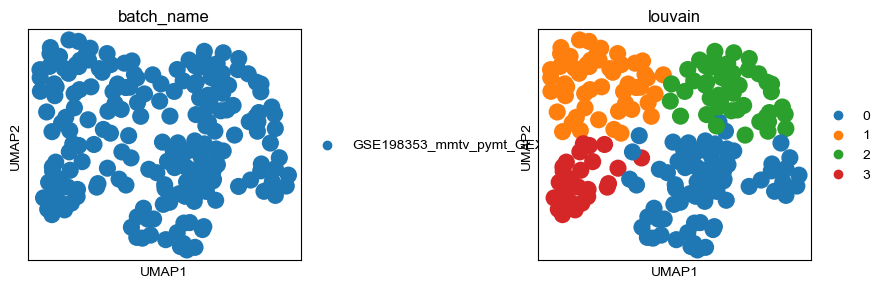

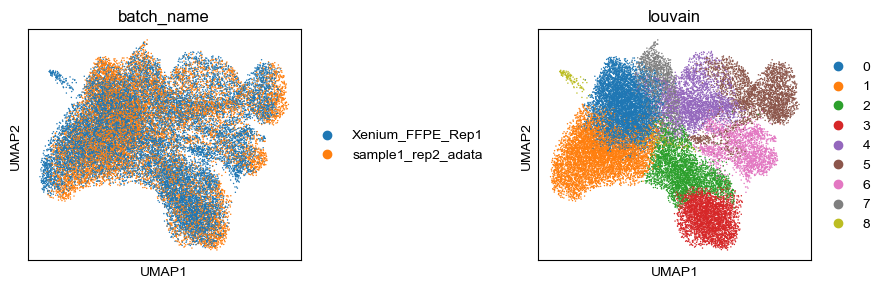

(28102, 32)


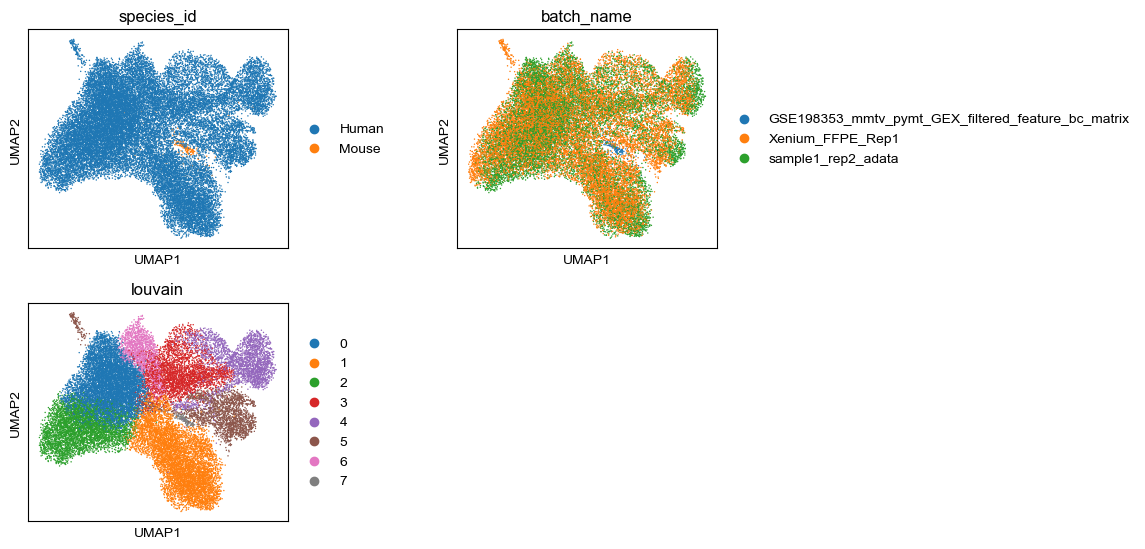

 33%|███▎      | 333/1000 [23:56<42:04,  3.78s/it]  

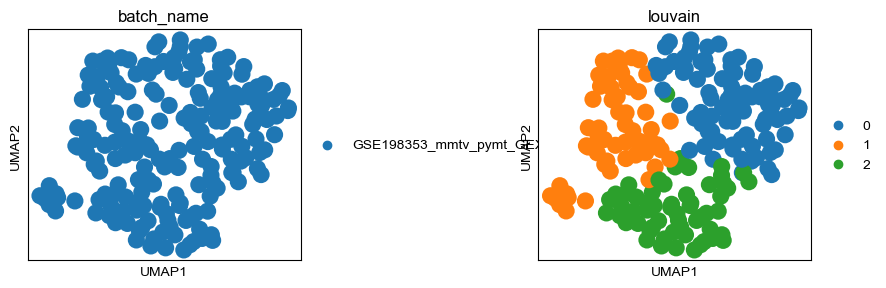

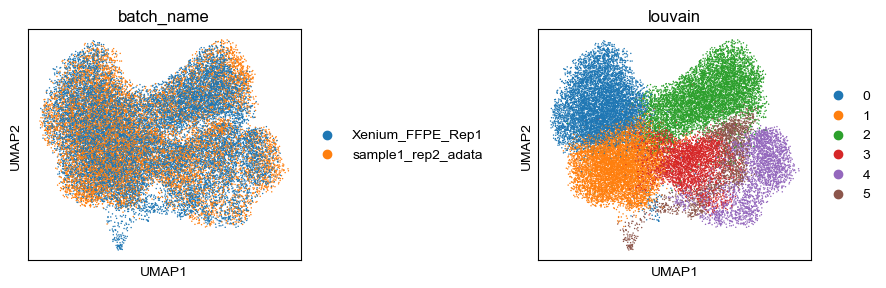

(28102, 32)


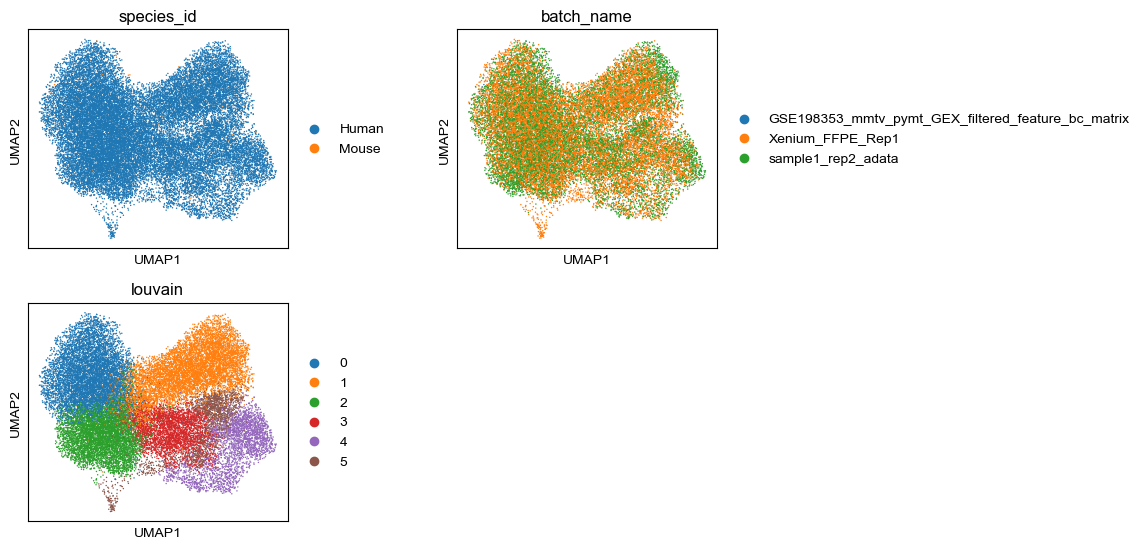

 67%|██████▋   | 666/1000 [46:12<23:35,  4.24s/it]  

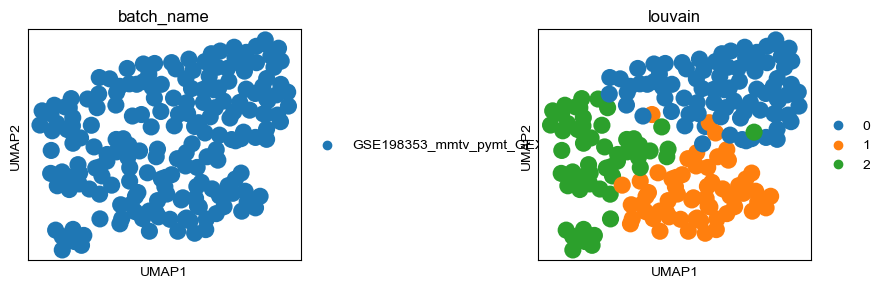

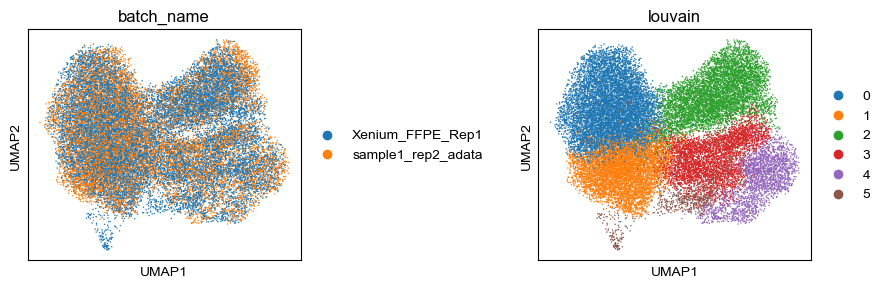

(28102, 32)


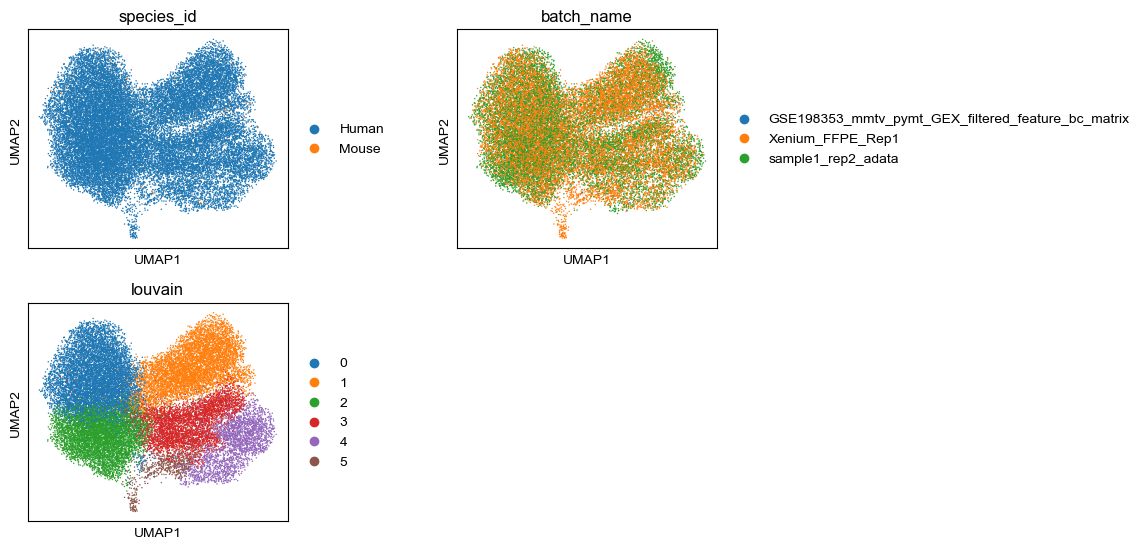

100%|██████████| 1000/1000 [1:11:39<00:00,  4.30s/it]


Clustering and UMAP of Cross Species STACAME:


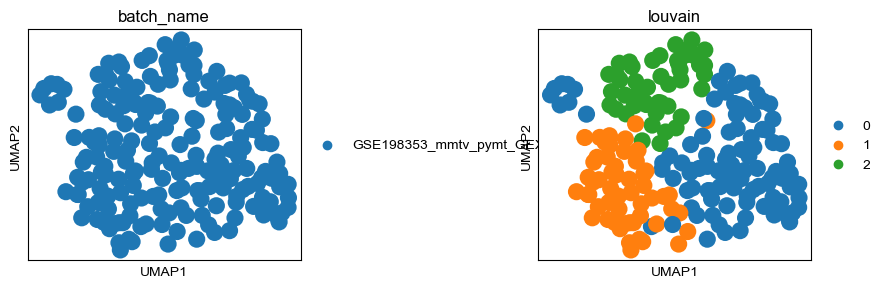

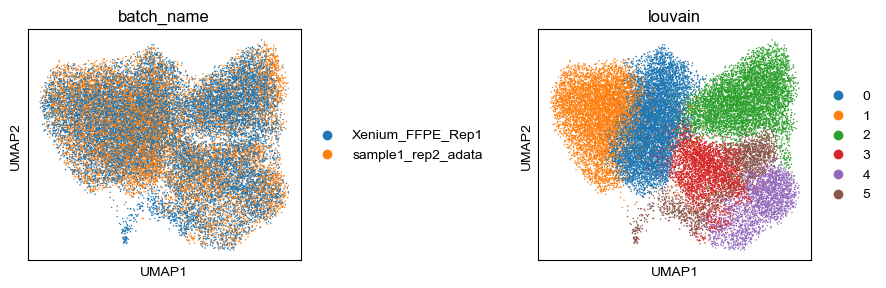

(28102, 32)


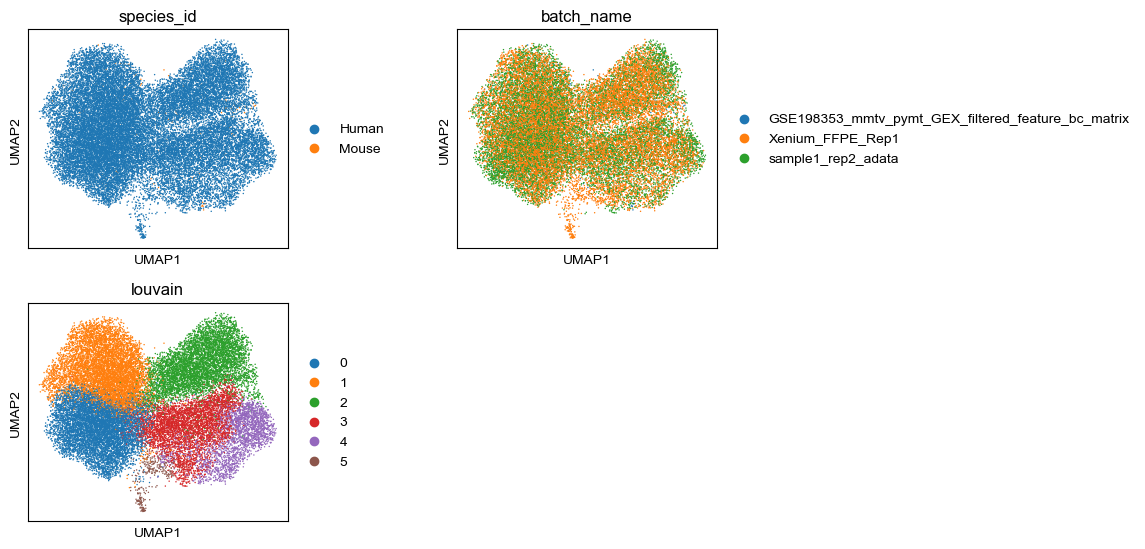

In [4]:
from STACAME.train_STACAME import train_STACAME_subgraph_GAN
used_device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
pretrain_device = used_device

for k,v in adata_dict.items():
    print(k, v)
adata_species_dict = train_STACAME_subgraph_GAN(adata_dict,
                           triplet_ind_species_dict = triplet_ind_species_dict, 
                           edge_ndarray_species = edge_ndarray_species, 
                           triplet_ind_sections_dict = triplet_ind_sections_dict, 
                           edge_ndarray_sections = edge_ndarray_sections, 
                           hidden_dims=[256, 32], 
                           verbose=False, 
                           knn_neigh = 50,  
                           key_added = 'STACAME',
                           device=used_device, 
                           pretrain_device = pretrain_device,
                           stagate_epoch={'Mouse':500, 'Human':300}, 
                           n_epochs_species=1000,  
                           margin_species=1,
                           lr=0.001, 
                           lr_species = 0.001,
                           beta=1,
                           mse_beta = 1, 
                           tri_beta = 10,  #50
                           mmd_beta = 5,  #300
                           gan_beta = 1,
                           gan_epoch = 3,                 
                           concate_pca_dim = None,
                          mmd_batch_size = 1978, 
                          batch_size = 5000,
                          batch_size_dict = {'Mouse':1978, 'Human':1978},
                          if_integrate_within_species = True,
                          if_knn_mnn_graph = True, adata_whole=adata_whole) #epochs = 1500, 




In [5]:
def merge_embedding(adata_dict, key_umap='STACAME', if_annotation = True):
    k = 0
    for species_id, adata in adata_dict.items():
        if k == 0:
            embedding_X = adata.obsm[key_umap]
            embedding_spatial = adata.obsm['spatial']
            embedding_obs_name = list(adata.obs_names)
            embedding_slice_name = list(adata.obs['slice_name']) 
            embedding_batch_name = list(adata.obs['batch_name'])
            embedding_species_id = list(adata.obs['species_id'])
            if 'annotation' in adata.obs:
                embedding_annotation = list(adata.obs['annotation']) 
        else:
            embedding_X = np.concatenate((embedding_X, adata.obsm[key_umap]), axis=0)
    
            embedding_spatial = np.concatenate((embedding_spatial, adata.obsm['spatial']), axis=0)
    
            embedding_obs_name = embedding_obs_name + list(adata.obs_names)
            embedding_slice_name = embedding_slice_name + list(adata.obs['slice_name']) 
            embedding_batch_name = embedding_batch_name + list(adata.obs['batch_name'])
            embedding_species_id = embedding_species_id + list(adata.obs['species_id'])
            if 'annotation' in adata.obs and 'embedding_annotation' in locals():
                embedding_annotation = embedding_annotation + list(adata.obs['annotation'])
            
        k += 1        
    
    adata_embedding = ad.AnnData(X = embedding_X)
    adata_embedding.obs_names = embedding_obs_name
    adata_embedding.obsm['spatial'] = embedding_spatial
    adata_embedding.obs['slice_name'] = embedding_slice_name
    adata_embedding.obs['batch_name'] = embedding_batch_name
    adata_embedding.obs['species_id'] = embedding_species_id
    if 'annotation' in adata_embedding.obs or if_annotation == True:
        if 'embedding_annotation' in locals():
            adata_embedding.obs['annotation'] = embedding_annotation
    if 'region_name' in adata_embedding.obs:
        if 'embedding_annotation' in locals():
            adata_embedding.obs['region_name'] = embedding_annotation
    adata_embedding.obsm[key_umap] = embedding_X
    return adata_embedding

In [6]:

for species_id, adata in adata_dict.items():
    print(adata.obsm['STACAME'].shape)
    if 'edgeList' in adata.uns.keys():
        del adata.uns['edgeList']
    adata.write(output_path + f'{species_id}.h5ad')
    adata_temp = adata[:, adata.uns['highly_variable']]
    adata_temp.write(output_path + f'adata_{species_id}_expression.h5ad')


#from STACAME.analysis import merge_embedding
adata_embedding = merge_embedding(adata_dict, key_umap = 'STACAME')

num_clusters = 16
STACAME.mclust_R(adata_embedding, num_cluster=num_clusters, used_obsm='STACAME')

adata_embedding.write(output_path + 'adata_embedding.h5ad')

(1978, 32)
(279055, 32)


   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
'Mclust' model object: (EEE,16) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   



In [7]:
adata_embedding = sc.read_h5ad(output_path + 'adata_embedding.h5ad')

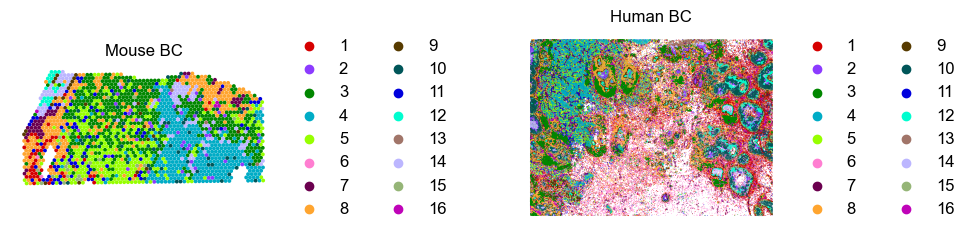

In [11]:
from sklearn.metrics import adjusted_rand_score as ari_score

Batch_list = []
for species_id in adata_dict.keys():
    adata = adata_embedding[adata_embedding.obs['species_id'].isin([species_id])]
    Batch_list.append(adata)

species_list = list(adata_dict.keys())

import matplotlib.pyplot as plt
spot_size = 100
title_size = 12

clust_list = [int(x+1) for x in range(16)]
color_list = sns.color_palette(cc.glasbey, n_colors=16)
clust_palette = {k:v for k,v in zip(clust_list, color_list)}

fig, ax = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={'wspace': 0.9, 'hspace': 0.4})
spot_size = 80
_sc_0 = sc.pl.spatial(Batch_list[0], img_key='hires', scale_factor=0.29620853, color=['mclust'], title=['Mouse BC'],
                      legend_loc='right margin', legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      palette = clust_palette,
                      spot_size=spot_size)
spot_size = 20
_sc_2 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=['Human BC'],
                      legend_loc='right margin', legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      palette = clust_palette,
                      spot_size=spot_size)

plt.savefig(output_path + 'common_domain.png')

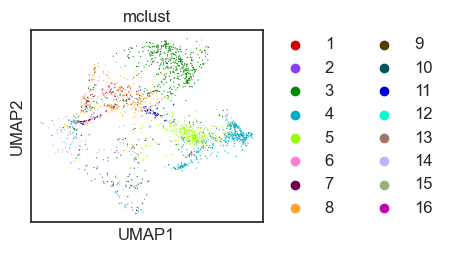

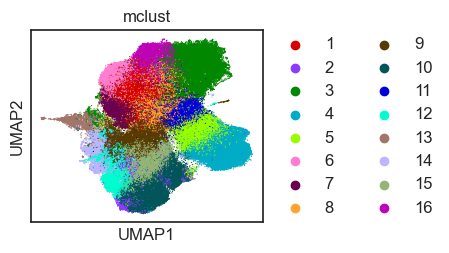

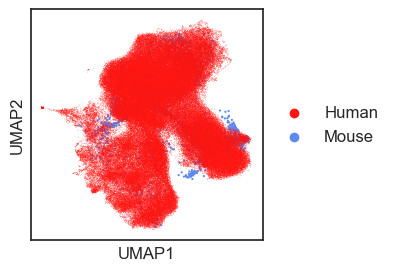

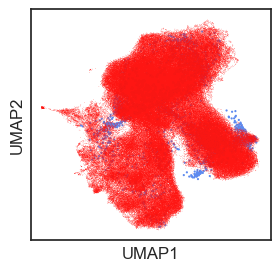

In [12]:
from STACAME.analysis import get_alignment_score, convert_dict2adata
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='white')
TINY_SIZE = 11 # 39
SMALL_SIZE = 11  # 42
MEDIUM_SIZE = 12  # 46
BIGGER_SIZE = 12  # 46

umap_neighbor = 30
umap_size_dict = {'Mouse':10, 'Human':0.5}
fig_format = 'jpg'
mouse_color = '#5D8AEF'
human_color = '#FE1613'
save_path = output_path + 'figs/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

fig_dpi = 100
plt.rc('axes', labelsize=MEDIUM_SIZE)  
plt.rc('xtick', labelsize=TINY_SIZE)  
plt.rc('ytick', labelsize=TINY_SIZE) 
plt.rc('legend', fontsize=MEDIUM_SIZE) 
plt.rc('figure', titlesize=BIGGER_SIZE) 

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

palette = {'Mouse':mouse_color, 'Human':human_color}
adata_embedding.obs['dataset'] = adata_embedding.obs['species_id']

sc.tl.pca(adata_embedding, svd_solver='arpack', n_comps=10)
sc.pp.neighbors(adata_embedding, n_neighbors=umap_neighbor, metric='cosine',
                use_rep='X')
sc.tl.umap(adata_embedding)

adata_mouse_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Mouse'])]
adata_human_embedding = adata_embedding[adata_embedding.obs['dataset'].isin(['Human'])]

adata_umap_size_list = [umap_size_dict[x] for x in adata_embedding.obs['dataset']]


with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    sc.pl.umap(adata_mouse_embedding, color=['mclust'], return_fig=True, legend_loc='right margin', 
               size=3, palette = clust_palette).savefig(
        save_path + 'umap_mouse.' + fig_format, format=fig_format)

sc.pp.neighbors(adata_human_embedding, n_neighbors=umap_neighbor, metric='cosine', use_rep='X')
sc.tl.umap(adata_human_embedding)

with plt.rc_context({"figure.figsize": (3, 2.5), "figure.dpi": (fig_dpi)}):
    sc.pl.umap(adata_human_embedding, color=['mclust'], return_fig=True, size=3,
               legend_loc='right margin', palette = clust_palette).savefig(
        save_path + 'umap_human.' + fig_format, format=fig_format)
rcParams["figure.subplot.left"] = 0.2
rcParams["figure.subplot.right"] = 0.9


rcParams["figure.subplot.left"] = 0.1
rcParams["figure.subplot.right"] = 0.68#0.6545
with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc='right margin', title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration_rightmargin.' + fig_format, format=fig_format)


rcParams["figure.subplot.right"] = 0.9
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": (fig_dpi)}):
    fg = sc.pl.umap(adata_embedding, color=['dataset'], return_fig=True, legend_loc=None, title='', size= adata_umap_size_list, palette=palette)
    plt.title('')
    fg.savefig(save_path + 'umap_dataset_after_integration.' + fig_format, format=fig_format)